In [18]:
import subprocess
import re
import sys
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

In [19]:
_DUR_RE = re.compile(r"(?P<val>[\d.]+)\s*(?P<unit>ns|µs|us|ms|s|m|h)")
_UNIT_TO_MS = {"ns": 1e-6, "µs": 1e-3, "us": 1e-3, "ms": 1, "s": 1000, "m": 60000, "h": 3600000}

def duration_to_ms(text: str) -> float:
    total_ms = 0.0
    for m in _DUR_RE.finditer(text):
        total_ms += float(m.group("val")) * _UNIT_TO_MS[m.group("unit")]
    return total_ms

In [20]:
SEQ_RE = re.compile(r"(?P<user1>\d+)\s*-\s*(?P<user2>\d+)\s*:\s*(?P<val>[-\d.]+)")
CON_RE = re.compile(r"(?P<user1>\d+)\s*-\s*(?P<user2>\d+)\s*:\s*(?P<val>[-\d.]+)")
TIME_RE = re.compile(r"(?:Sequential|Concurrent)\s+similarities\s+computed\s+in\s+(?P<duration>.+?)(?:\s+\(workers=(?P<workers>\d+)\))?,\s+pairs=(?P<pairs>\d+)", re.I)
USERS_RE = re.compile(r"Users=(?P<users>\d+)\s+Items=(?P<items>\d+)")
TRAIN_RE = re.compile(r"Train users=(?P<train_users>\d+)\s+Test cases=(?P<test_cases>\d+)")
SAMPLE_RE = re.compile(r"Too many users \((?P<total>\d+)\), sampling first (?P<sample>\d+) for pairwise similarities")

# Default absolute path for the dataset
_DEFAULT_DATA_PATH = "/home/giorgio6846/Code/Clases/Programacion-CyD/PCyD-TP/data/steam_reviews.csv"

def run_algo(go_file: Path, alg: str, 
            sample_users: int = 0, sample_items: int = 0, goroutines: int = 0, data_path: str = _DEFAULT_DATA_PATH):
    # Build command and include the num_cores flag (goroutines/workers) and data path
    cmd = [
        "go", "run", str(go_file),
        f"--algorithm={alg}",
        f"--sample_users={sample_users}",
        f"--sample_items={sample_items}",
        f"--num_cores={goroutines}",
        f"--data={data_path}",
    ]
    res = subprocess.run(cmd, capture_output=True, text=True, check=True)
    stdout = res.stdout.splitlines()

    seq_pairs, con_pairs = [], []
    seq_time, con_time = None, None
    seq_workers = con_workers = None
    pairs_seq = pairs_con = None
    users = items = train_users = test_cases = None
    sampled_total = sampled_first = None
    in_seq_pairs = in_con_pairs = False

    for line in stdout:
        if "Top-10 similar user pairs (seq):" in line:
            in_seq_pairs = True
            in_con_pairs = False
            continue
        elif "Top-10 similar user pairs (con):" in line:
            in_seq_pairs = False
            in_con_pairs = True
            continue
        elif "Time" not in line and (in_seq_pairs or in_con_pairs):
            if m := SEQ_RE.search(line):
                pairs = seq_pairs if in_seq_pairs else con_pairs
                pairs.append({
                    "user1": int(m.group("user1")),
                    "user2": int(m.group("user2")),
                    "value": float(m.group("val"))
                })
        elif (m := TIME_RE.search(line)):
            ms = duration_to_ms(m.group("duration"))
            # extract optional workers and pairs
            w = m.groupdict().get("workers")
            p = m.groupdict().get("pairs")
            if "Sequential" in line:
                seq_time = ms
                if w:
                    seq_workers = int(w)
                if p:
                    pairs_seq = int(p)
            else:
                con_time = ms
                if w:
                    con_workers = int(w)
                if p:
                    pairs_con = int(p)
        elif (m := USERS_RE.search(line)):
            users = int(m.group("users"))
            items = int(m.group("items"))
        elif (m := TRAIN_RE.search(line)):
            train_users = int(m.group("train_users"))
            test_cases = int(m.group("test_cases"))
        elif (m := SAMPLE_RE.search(line)):
            sampled_total = int(m.group("total"))
            sampled_first = int(m.group("sample"))

    # Attach metadata and return records ready for DataFrame ingestion
    records = []
    if seq_time is not None and seq_pairs:
        rec = {
            "algorithm": alg,
            "mode": "sequential",
            "value": np.mean([p["value"] for p in seq_pairs]),
            "duration_ms": seq_time,
            "top_pairs": seq_pairs,
            "dim": sample_items,
            "goroutines": goroutines,
            "data_path": data_path,
            # runtime-reported fields
            "users": users,
            "items": items,
            "train_users": train_users,
            "test_cases": test_cases,
            "sampled_total": sampled_total,
            "sampled_first": sampled_first,
            "reported_workers": seq_workers,
            "reported_pairs": pairs_seq,
        }
        records.append(rec)
    if con_time is not None and con_pairs:
        rec = {
            "algorithm": alg,
            "mode": "concurrent",
            "value": np.mean([p["value"] for p in con_pairs]),
            "duration_ms": con_time,
            "top_pairs": con_pairs,
            "dim": sample_items,
            "goroutines": goroutines,
            "data_path": data_path,
            # runtime-reported fields
            "users": users,
            "items": items,
            "train_users": train_users,
            "test_cases": test_cases,
            "sampled_total": sampled_total,
            "sampled_first": sampled_first,
            "reported_workers": con_workers,
            "reported_pairs": pairs_con,
        }
        records.append(rec)

    return records, "\n".join(stdout)


In [ ]:
def benchmark(go_file, algs, goroutines_list,
            sample_users_list=[100, 1000], sample_items_list=[0], repeats=3, data_path: str = _DEFAULT_DATA_PATH):
    """Run benchmarks sweeping sample_users and sample_items lists.

    Returns a pandas DataFrame with columns including:
      algorithm, mode, value, duration_ms, top_pairs, dim, goroutines,
      users, items, train_users, test_cases, sampled_total, sampled_first,
      reported_workers, reported_pairs, run, sample_users, sample_items
    """
    records = []

    for sample_users in sample_users_list:
        for sample_items in sample_items_list:
            for goroutines in goroutines_list:
                for alg in algs:
                    for r in range(repeats):
                        recs, _ = run_algo(
                            go_file=go_file,
                            alg=alg,
                            sample_users=sample_users,
                            sample_items=sample_items,
                            goroutines=goroutines,
                            data_path=data_path,
                        )
                        for rec in recs:
                            rec["run"] = r
                            rec["goroutines"] = goroutines
                            rec["sample_users"] = sample_users
                            rec["sample_items"] = sample_items
                            records.append(rec)
    return pd.DataFrame(records)

# Example usage (small sweep for quick testing):
df = benchmark(
    go_file=Path("tp.go"),
    algs=["cosine", "pearson"],
    goroutines_list=[1, 4],
    sample_users_list=[100, 500],
    sample_items_list=[0],
    repeats=1,
    data_path=_DEFAULT_DATA_PATH,
)


{'algorithm': 'cosine', 'mode': 'sequential', 'value': np.float64(1.0), 'duration_ms': 48.395952, 'top_pairs': [{'user1': 76561198145072397, 'user2': 76561198166244602, 'value': 1.0}, {'user1': 76561198130909623, 'user2': 76561199069638576, 'value': 1.0}, {'user1': 76561197963542681, 'user2': 76561198163273436, 'value': 1.0}, {'user1': 76561197963542681, 'user2': 76561199033607297, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198786045730, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198846501504, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198399270978, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198182528193, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198049411245, 'value': 1.0}, {'user1': 76561198025813077, 'user2': 76561198045851493, 'value': 1.0}], 'dim': 0, 'goroutines': 1, 'data_path': '/home/giorgio6846/Code/Clases/Programacion-CyD/PCyD-TP/data/steam_reviews.csv', 'users': 1000, 'items': 315, 'train_users': 10

In [27]:
df.head()

,algorithm,mode,value,duration_ms,top_pairs,dim,goroutines,data_path,users,items,train_users,test_cases,sampled_total,sampled_first,reported_workers,reported_pairs,run
0,cosine,sequential,1.0,48.395952,"[{'user1': 76561198145072397, 'user2': 7656119...",0,1,/home/giorgio6846/Code/Clases/Programacion-CyD...,1000,315,1000,299,None,None,None,10997,0
1,cosine,sequential,1.0,49.264368,"[{'user1': 76561198271859842, 'user2': 7656119...",0,1,/home/giorgio6846/Code/Clases/Programacion-CyD...,1000,315,1000,296,None,None,None,12160,1
2,cosine,sequential,1.0,48.932077,"[{'user1': 76561198209107631, 'user2': 7656119...",0,1,/home/giorgio6846/Code/Clases/Programacion-CyD...,1000,315,1000,327,None,None,None,11742,2
3,cosine,sequential,1.0,47.843378,"[{'user1': 76561198127069017, 'user2': 7656119...",0,1,/home/giorgio6846/Code/Clases/Programacion-CyD...,1000,315,1000,327,None,None,None,11888,3
4,cosine,sequential,1.0,48.961963,"[{'user1': 76561198062179866, 'user2': 7656119...",0,1,/home/giorgio6846/Code/Clases/Programacion-CyD...,1000,315,1000,338,None,None,None,13962,4


In [47]:
# Build per-run pivot to pair seq/con, then average to be robust
# Ensure columns exist and normalize names
if df is None or df.empty:
    raise ValueError("DataFrame 'df' is empty. Run `benchmark` first or check data_path.")

# normalize dim/sample_items
if 'sample_items' not in df.columns:
    if 'dim' in df.columns:
        df['sample_items'] = df['dim']
    else:
        df['sample_items'] = np.nan

if 'sample_users' not in df.columns:
    df['sample_users'] = np.nan

if 'goroutines' not in df.columns:
    df['goroutines'] = np.nan

# Pivot table: create columns for modes
per_run = df.pivot_table(
    index=["algorithm","sample_items","goroutines","run","sample_users"],
    columns="mode",
    values="duration_ms",
    aggfunc="first",
).reset_index()

# After pivot, mode columns may become a MultiIndex if pandas version differs; flatten
if isinstance(per_run.columns, pd.MultiIndex):
    per_run.columns = ['_'.join([str(c) for c in col if c]) if isinstance(col, tuple) else col for col in per_run.columns]
    # try to find sequential and concurrent columns
    if 'duration_ms_sequential' in per_run.columns:
        per_run = per_run.rename(columns={'duration_ms_sequential': 'sequential', 'duration_ms_concurrent': 'concurrent'})

# Ensure both mode columns exist to avoid KeyError
if 'sequential' not in per_run.columns:
    per_run['sequential'] = np.nan
if 'concurrent' not in per_run.columns:
    per_run['concurrent'] = np.nan

# Compute ratios per run safely (avoid division by zero)
with np.errstate(divide='ignore', invalid='ignore'):
    per_run['ratio_con_over_seq'] = np.where(
        per_run['sequential'].fillna(0) == 0,
        np.nan,
        per_run['concurrent'] / per_run['sequential']
    )

per_run['pct_con_of_seq'] = 100 * per_run['ratio_con_over_seq']
per_run['pct_improve'] = 100 * (1 - per_run['ratio_con_over_seq'])

# If no valid ratio rows, bail out with a message
if per_run['ratio_con_over_seq'].dropna().empty:
    print("No paired sequential/concurrent records found after pivot — skipping summary/plots.")
else:
    # Average across repeats for plotting
    pct_summary = per_run.groupby(["algorithm","sample_items","goroutines"], as_index=False).agg(
        mean_pct_con_of_seq=("pct_con_of_seq","mean"),
        sd_pct_con_of_seq=("pct_con_of_seq","std"),
        mean_pct_improve=("pct_improve","mean"),
        sd_pct_improve=("pct_improve","std"),
    )

    # A) Concurrent as % of sequential (target < 100%)
    if pct_summary.empty:
        print("pct_summary is empty — nothing to plot.")
    else:
        g1 = sns.relplot(
            data=pct_summary, kind="line",
            x="goroutines", y="mean_pct_con_of_seq",
            hue="sample_items", col="algorithm", col_wrap=3,
            markers=True, dashes=False,
            errorbar=None
        )
        # draw baseline line on all axes
        for ax in g1.axes.flatten():
            ax.axhline(100, ls="--", lw=1, color="gray")  # baseline: equal speed
        g1.set_axis_labels("Goroutines", "Concurrent as % of Sequential (↓ better)")
        g1.fig.suptitle("Concurrent runtime relative to Sequential (mean across repeats)", y=1.02)
        plt.show()

        # B) % improvement (target > 0%)
        g2 = sns.relplot(
            data=pct_summary, kind="line",
            x="goroutines", y="mean_pct_improve",
            hue="sample_items", col="algorithm", col_wrap=3,
            markers=True, dashes=False,
            errorbar=None
        )
        for ax in g2.axes.flatten():
            ax.axhline(0, ls="--", lw=1, color="gray")  # baseline: no improvement
        g2.set_axis_labels("Goroutines", "Improvement of Concurrent vs Sequential (%) (↑ better)")
        g2.fig.suptitle("Percentage improvement from concurrency (mean across repeats)", y=1.02)
        plt.show()

    # --- Additional comparison plots: Sequential vs Concurrent ---
    # Keep the per-run pivot and filter to rows where both modes are present
    per_run_valid = per_run.dropna(subset=['sequential', 'concurrent']).copy()
    if per_run_valid.empty:
        print('No paired sequential/concurrent rows for direct comparison. Skipping comparison plots.')
    else:
        # 1) Scatter: sequential vs concurrent (each point = one run)
        plt.figure(figsize=(7, 7))
        sns.scatterplot(
            data=per_run_valid,
            x='sequential', y='concurrent',
            hue='goroutines', style='sample_items',
            palette='viridis', s=80
        )
        # diagonal baseline (equal runtime)
        maxv = per_run_valid[['sequential', 'concurrent']].replace(0, np.nan).max().max()
        if np.isnan(maxv):
            maxv = max(per_run_valid[['sequential', 'concurrent']].max().max(), 1)
        pad = maxv * 0.05
        lim = maxv + pad
        plt.plot([0.1, lim], [0.1, lim], ls='--', color='gray')
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Sequential duration (ms)')
        plt.ylabel('Concurrent duration (ms)')
        plt.title('Sequential vs Concurrent per-run (log scale)')
        plt.grid(True, which='both', ls=':', linewidth=0.5)
        plt.tight_layout()
        plt.show()

        # 2) Grouped bar: mean durations by mode for each algorithm and goroutines/sample_items
        mean_df = df.groupby(['algorithm', 'goroutines', 'sample_items', 'mode'], as_index=False).agg(mean_duration=('duration_ms', 'mean'))
        if mean_df.empty:
            print('No mean duration data available for grouped bar plot.')
        else:
            g = sns.catplot(
                data=mean_df,
                kind='bar',
                x='goroutines', y='mean_duration', hue='mode',
                col='algorithm', col_wrap=3,
                height=4, aspect=1.2
            )
            g.set_axis_labels('Goroutines', 'Mean duration (ms)')
            g.fig.suptitle('Mean durations by mode (sequential vs concurrent)', y=1.02)
            plt.show()

No paired sequential/concurrent records found after pivot — skipping summary/plots.


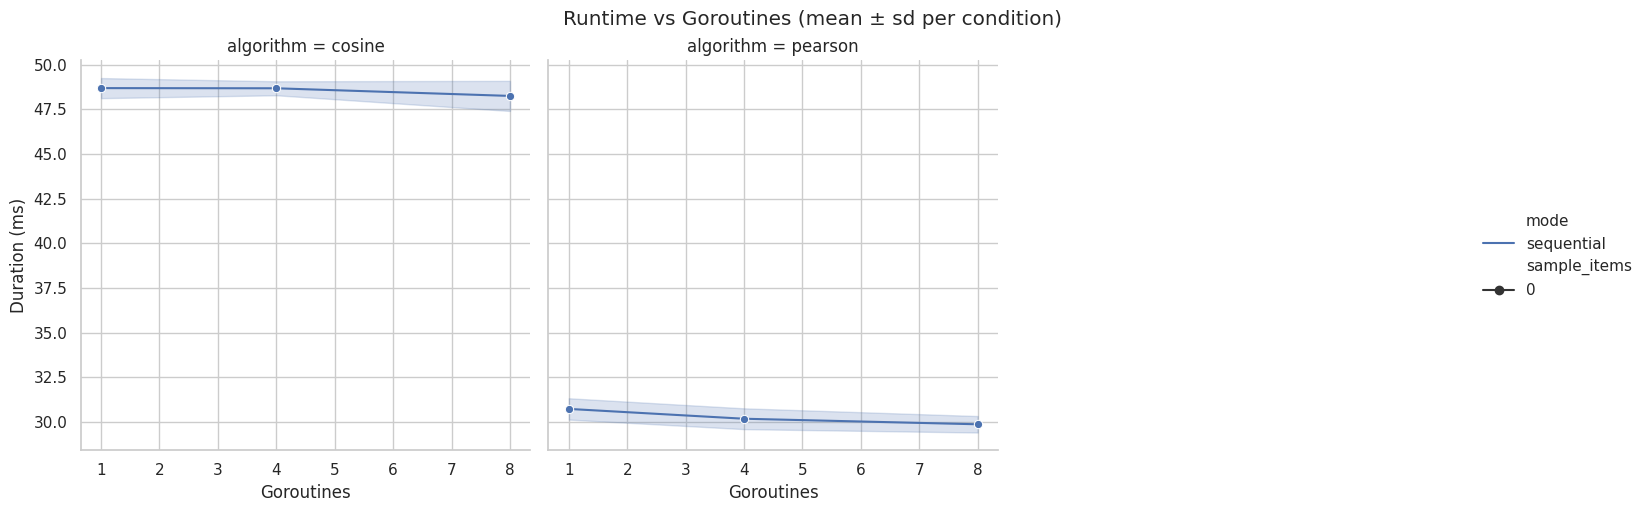

In [48]:
g = sns.relplot(
    data=df,
    kind="line",
    x="goroutines", y="duration_ms",
    hue="mode", style="sample_items",
    col="algorithm", col_wrap=3,
    markers=True, dashes=False,
    errorbar=("sd")  # show variability from your repeats
)
# Ensure axis labels and title
g.set_axis_labels("Goroutines", "Duration (ms)")
g.fig.suptitle("Runtime vs Goroutines (mean ± sd per condition)", y=1.02)
plt.show()